# LSTM Temporal Model

Goal: learn the normal temporal behavior of the subsystem.

Approach:
- train an LSTM on normal telemetry windows
- combine reconstruction and prediction losses
- use validation scores to set an anomaly threshold

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

plt.style.use("default")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Load Windowed Data

Shape:
(num_windows, window_size, num_sensors)

In [2]:
X_train = np.load("data/X_train.npy")
X_val   = np.load("data/X_val.npy")
X_test  = np.load("data/X_test.npy")

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (233, 80, 12)
Val shape: (68, 80, 12)
Test shape: (68, 80, 12)


## Convert to PyTorch Tensors

In [3]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(X_train_t), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t), batch_size=64)

### Model Structure

Input sequence → LSTM → two linear heads

Outputs:
1. reconstruction of the full sequence
2. prediction of the final timestep

In [4]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc_recon = nn.Linear(hidden_dim, input_dim)
        self.fc_pred  = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        
        # Reconstruction
        recon = self.fc_recon(out)
        
        # Prediction (last hidden state)
        last_hidden = out[:, -1, :]
        pred = self.fc_pred(last_hidden)
        
        return recon, pred


input_dim = X_train.shape[2]
model = LSTMModel(input_dim).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

LSTMModel(
  (lstm): LSTM(12, 64, batch_first=True)
  (fc_recon): Linear(in_features=64, out_features=12, bias=True)
  (fc_pred): Linear(in_features=64, out_features=12, bias=True)
)


## Training

Loss combines two objectives:

Reconstruction loss:
rebuild the full telemetry window.

Prediction loss:
predict the final timestep of the sequence.

In [5]:
num_epochs = 20

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    
    for (batch,) in train_loader:
        optimizer.zero_grad()
        
        recon, pred = model(batch)
        
        loss_recon = criterion(recon, batch)
        target = batch[:, -1, :]
        loss_pred = criterion(pred, target)
        
        loss = loss_recon + loss_pred
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    train_losses.append(total_train_loss)
    
    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for (batch,) in val_loader:
            recon, pred = model(batch)
            loss_recon = criterion(recon, batch)
            target = batch[:, -1, :]
            loss_pred = criterion(pred, target)
            total_val_loss += (loss_recon + loss_pred).item()
    
    val_losses.append(total_val_loss)
    
    print(f"Epoch {epoch+1}: Train={total_train_loss:.4f}, Val={total_val_loss:.4f}")

Epoch 1: Train=8.5661, Val=4.7051
Epoch 2: Train=8.7041, Val=4.6507
Epoch 3: Train=8.4583, Val=4.5993
Epoch 4: Train=8.7697, Val=4.5460
Epoch 5: Train=8.2188, Val=4.4909
Epoch 6: Train=8.1534, Val=4.4296
Epoch 7: Train=8.2509, Val=4.3620
Epoch 8: Train=8.4661, Val=4.2869
Epoch 9: Train=8.2447, Val=4.1934
Epoch 10: Train=8.0416, Val=4.0790
Epoch 11: Train=7.4486, Val=3.9465
Epoch 12: Train=7.2447, Val=3.8039
Epoch 13: Train=7.5518, Val=3.6736
Epoch 14: Train=7.4363, Val=3.5635
Epoch 15: Train=6.6682, Val=3.4314
Epoch 16: Train=6.4090, Val=3.3024
Epoch 17: Train=6.3440, Val=3.1591
Epoch 18: Train=5.9449, Val=3.0115
Epoch 19: Train=6.0361, Val=2.8611
Epoch 20: Train=5.2731, Val=2.7305


## Training Curve

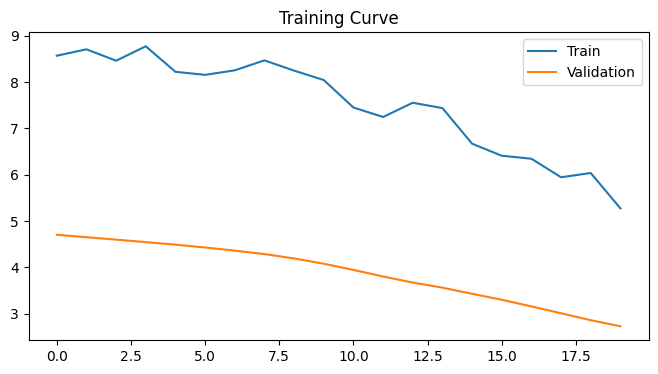

In [6]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Training Curve")
plt.show()

## Anomaly Scoring

Anomaly score = reconstruction error + prediction error.

Validation windows are used to estimate the threshold.
Test windows are then evaluated against this threshold.

In [7]:
model.eval()

val_loader_full = DataLoader(TensorDataset(X_val_t), batch_size=64)

val_scores = []

with torch.no_grad():
    for (batch,) in val_loader_full:
        recon, pred = model(batch)
        
        loss_recon = torch.mean((recon - batch)**2, dim=(1,2))
        target = batch[:, -1, :]
        loss_pred = torch.mean((pred - target)**2, dim=1)
        
        score = loss_recon + loss_pred
        val_scores.extend(score.cpu().numpy())

val_scores = np.array(val_scores)
threshold = np.percentile(val_scores, 95)

print("Threshold:", threshold)

Threshold: 2.1741824


In [8]:
# Score Test Windows

test_loader = DataLoader(TensorDataset(X_test_t), batch_size=64)

test_scores = []

with torch.no_grad():
    for (batch,) in test_loader:
        recon, pred = model(batch)
        
        loss_recon = torch.mean((recon - batch)**2, dim=(1,2))
        target = batch[:, -1, :]
        loss_pred = torch.mean((pred - target)**2, dim=1)
        
        score = loss_recon + loss_pred
        test_scores.extend(score.cpu().numpy())

test_scores = np.array(test_scores)
anomalies = test_scores > threshold

print("Anomalies detected:", anomalies.sum())

Anomalies detected: 2


## Visualization

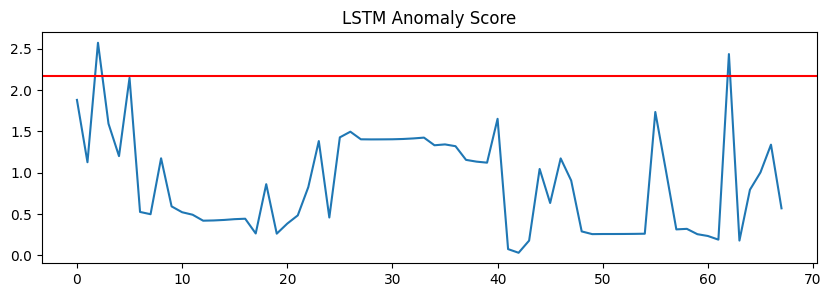

In [9]:
plt.figure(figsize=(10,3))
plt.plot(test_scores)
plt.axhline(threshold, color="red")
plt.title("LSTM Anomaly Score")
plt.show()

## Observations

The LSTM captures temporal structure that classical baselines miss.

Compared with PCA reconstruction, the model responds better to
contextual anomalies where individual sensor values may appear normal
but the temporal pattern is unusual.

These outputs will later be combined with the linear state-space model
in the hybrid detector.

In [10]:
np.save("data/lstm_test_scores.npy", test_scores)
np.save("data/lstm_anomalies.npy", anomalies)

print("Saved LSTM outputs.")

Saved LSTM outputs.
